# Food-101 CNN Final Project

Modular PyTorch workflow for Food-101 classification with a CNN baseline, transfer learning, staged training, evaluation diagnostics, inference, and export.

In [ ]:
import os
import shutil
import subprocess
import sys
import tarfile
from pathlib import Path

# Local macOS workaround for duplicate OpenMP runtimes in some Conda/Torch builds.
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

try:
    import google.colab  # type: ignore[import-not-found]

    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

DRIVE_PROJECT_ROOT = Path("/content/drive/MyDrive/food101-cnn")
BUNDLE_REPOSITORY_ROOT = Path("/content/food101-cnn")
COLAB_BUNDLE_PATH = DRIVE_PROJECT_ROOT / "transfer" / "food101_colab_bundle.tar.gz"
BUNDLE_EXTRACT_ROOT = Path("/content")

# Local execution is the default. In Colab, either clone/copy the repo into the
# runtime or set RUN_UNPACK_LOCAL_BUNDLE=True after uploading the transfer bundle.
RUN_UNPACK_LOCAL_BUNDLE = False
OVERWRITE_UNPACKED_BUNDLE = False
REPOSITORY_ROOT_OVERRIDE = ""
RUN_INSTALL = False

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")

    if RUN_UNPACK_LOCAL_BUNDLE:
        if not COLAB_BUNDLE_PATH.is_file():
            raise FileNotFoundError(f"Colab bundle not found: {COLAB_BUNDLE_PATH}")
        if BUNDLE_REPOSITORY_ROOT.exists() and OVERWRITE_UNPACKED_BUNDLE:
            shutil.rmtree(BUNDLE_REPOSITORY_ROOT)
        with tarfile.open(COLAB_BUNDLE_PATH, "r:gz") as archive:
            archive.extractall(BUNDLE_EXTRACT_ROOT)


def is_repository_root(path: Path) -> bool:
    return (path / "pyproject.toml").is_file() and (path / "src" / "food101_cnn").is_dir()


def repository_candidates() -> list[Path]:
    cwd = Path.cwd().resolve()
    candidates = []
    if REPOSITORY_ROOT_OVERRIDE:
        candidates.append(Path(REPOSITORY_ROOT_OVERRIDE).expanduser())
    candidates.extend([cwd, *cwd.parents])
    if IN_COLAB:
        candidates.extend([
            BUNDLE_REPOSITORY_ROOT,
            DRIVE_PROJECT_ROOT,
            DRIVE_PROJECT_ROOT / "repo",
            DRIVE_PROJECT_ROOT / "repository",
        ])

    unique_candidates = []
    seen = set()
    for candidate in candidates:
        resolved = candidate.expanduser().resolve()
        if resolved not in seen:
            unique_candidates.append(resolved)
            seen.add(resolved)
    return unique_candidates


def find_repository_root() -> Path:
    for candidate in repository_candidates():
        if is_repository_root(candidate):
            return candidate
    searched = "\n".join(str(candidate) for candidate in repository_candidates())
    raise FileNotFoundError(
        "Could not locate the Food-101 CNN repository source. In Colab, clone or "
        "copy the repository, upload and unpack the transfer bundle, or set "
        "REPOSITORY_ROOT_OVERRIDE. Searched:\n"
        f"{searched}"
    )


PROJECT_ROOT = find_repository_root()
os.chdir(PROJECT_ROOT)

MATPLOTLIB_CONFIG_DIR = PROJECT_ROOT / "outputs" / ".matplotlib"
MATPLOTLIB_CONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MATPLOTLIB_CONFIG_DIR))

SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

existing_pythonpath = os.environ.get("PYTHONPATH", "")
pythonpath_parts = [str(SRC_ROOT), *(part for part in existing_pythonpath.split(os.pathsep) if part)]
os.environ["PYTHONPATH"] = os.pathsep.join(dict.fromkeys(pythonpath_parts))

if RUN_INSTALL:
    subprocess.run([sys.executable, "-m", "pip", "install", "-e", ".[dev]"], cwd=PROJECT_ROOT, check=True)

RUN_DATA_PREP = False
RUN_TRAINING = False
RUN_FINAL_EVAL = True
RUN_POSTPROCESSING = True
RUN_BASELINE_QUALITATIVE = False
RUN_INFERENCE_EXPORT = True

print({
    "runtime": "colab" if IN_COLAB else "local",
    "project_root": str(PROJECT_ROOT),
    "pythonpath_first": os.environ["PYTHONPATH"].split(os.pathsep)[0],
})


### Runtime Setup and Imports

The setup cell supports the local repository first. When running in Colab, it mounts Drive only inside Colab, locates a staged copy of this repository, and adds `src/` to `PYTHONPATH` before importing `food101_cnn`.

In [ ]:
import ast
import json
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Image as DisplayImage, Markdown, display
from matplotlib.patches import FancyBboxPatch
from PIL import Image
from torch.utils.data import DataLoader, TensorDataset

from food101_cnn.config import load_config
from food101_cnn.data.transforms import build_eval_transform, build_train_transform, resize_with_padding
from food101_cnn.evaluation.calibration import calibration_report, load_calibration_report_json, save_calibration_artifacts_from_report
from food101_cnn.evaluation.errors import collect_misclassifications, normalize_prediction_dataframe, save_error_galleries
from food101_cnn.evaluation.class_report import build_classification_report_from_confusion, top_best_classes, top_worst_classes
from food101_cnn.evaluation.confusion import load_confusion_matrix_csv, top_misclassification_pairs
from food101_cnn.evaluation.feature_retrieval import find_nearest_feature_neighbors, plot_feature_neighbor_panel
from food101_cnn.evaluation.metrics import classification_metrics_from_logits
from food101_cnn.evaluation.model_comparison import save_global_model_comparison_plots
from food101_cnn.evaluation.plot_training import save_training_curve_plots
from food101_cnn.evaluation.qualitative import plot_top5_prediction_panel
from food101_cnn.evaluation.tensorboard_reader import load_tensorboard_scalars
from food101_cnn.interpretability.gradcam import save_gradcam_sets_from_predictions
from food101_cnn.inference.predict import load_class_names
from food101_cnn.models.registry import SUPPORTED_MODELS, build_model
from food101_cnn.training.loops import train_one_epoch, validate_one_epoch
from food101_cnn.training.losses import build_classification_loss
from food101_cnn.training.train import build_optimizer
from food101_cnn.utils.device import select_device
from food101_cnn.utils.runs import (
    latest_run_for_model,
    list_run_manifests,
    manifest_to_comparison_row,
    manifest_with_resolved_artifacts,
    resolve_manifest_artifact,
    select_best_run,
)
from food101_cnn.utils.seed import seed_everything


## 1. Introduction

The task is multi-class food image classification over the 101 Food-101 categories. The main metric is top-5 accuracy because visually similar dishes can be plausible alternatives, while top-1 accuracy, macro F1, calibration, per-class diagnostics, and latency provide complementary checks.

## 2. Dataset Description

The pipeline uses original Food-101 images and preserves the official split. The official training split is divided into train and internal validation subsets. The official test split is reserved for final evaluation only.

In [4]:
PROJECT_CONFIG_PATH = PROJECT_ROOT / "configs" / "baseline_cnn.yaml"
config = load_config(PROJECT_CONFIG_PATH, project_root=PROJECT_ROOT)
seed_everything(int(config["project"]["seed"]))
device = select_device(str(config["training"].get("device", "auto")))
REPORT_REFERENCE_MODEL = config["model"]["name"]

pd.DataFrame(
    [
        {"field": "project", "value": config["project"]["name"]},
        {"field": "seed", "value": config["project"]["seed"]},
        {"field": "reference_config", "value": PROJECT_CONFIG_PATH.relative_to(PROJECT_ROOT).as_posix()},
        {"field": "reference_model", "value": REPORT_REFERENCE_MODEL},
        {"field": "num_classes", "value": config["model"]["num_classes"]},
        {"field": "image_size", "value": config["data"]["image_size"]},
        {"field": "device", "value": str(device)},
    ]
)

,field,value
0,project,food101_cnn
1,seed,42
2,reference_config,configs/baseline_cnn.yaml
3,reference_model,baseline_cnn
4,num_classes,101
5,image_size,224
6,device,mps


## 3. Hardware and Implementation Constraints

The local target is Apple Silicon with limited unified memory. The project therefore uses conservative batch sizes, disk-based caching, MPS or CPU fallback, and staged training. EfficientNet-B0 is treated as the most practical local transfer-learning candidate because of its parameter efficiency, while the final model is selected from completed run metrics rather than assumed in advance.

## 4. Project Methodology

The workflow is staged: validate the data pipeline, run a small sanity check, train a CNN-from-scratch baseline, train an EfficientNet-B0 transfer model, compare backbones, then evaluate the selected final model on the official test split.

## 5. Data Acquisition and Validation

Data preparation uses the project modules for download, official split indexing, and image validation. The cell is guarded because the full dataset is large and should only be prepared intentionally.

In [5]:
if RUN_DATA_PREP:
    from food101_cnn.data.dataset import generate_dataset_index
    from food101_cnn.data.download import download_food101, verify_food101_structure
    from food101_cnn.data.validation import validate_index, validation_summary

    data_root = PROJECT_ROOT / config["data"]["root_dir"]
    index_csv = PROJECT_ROOT / "data" / "reports" / "dataset_index.csv"
    report_csv = PROJECT_ROOT / "data" / "reports" / "image_validation_report.csv"
    corrupted_txt = PROJECT_ROOT / "data" / "reports" / "corrupted_images.txt"

    download_food101(data_root)
    print(verify_food101_structure(data_root))
    records = generate_dataset_index(
        data_root,
        output_csv=index_csv,
        validation_fraction=float(config["data"]["validation_fraction"]),
        seed=int(config["project"]["seed"]),
    )
    results = validate_index(index_csv, report_csv=report_csv, corrupted_output=corrupted_txt)
    print({"records": len(records), **validation_summary(results)})
else:
    print("Skipped full data preparation. Set RUN_DATA_PREP = True to execute it.")

Skipped full data preparation. Set RUN_DATA_PREP = True to execute it.


## 6. Preprocessing and Augmentation

Evaluation preprocessing applies EXIF orientation correction, RGB conversion, padded resize to the configured square size, tensor conversion, and ImageNet normalization. Training adds conservative horizontal flip, color jitter, and small rotation.

In [6]:
sample_image = Image.new("RGB", (320, 180), color=(180, 80, 40))
padded = resize_with_padding(sample_image, size=224)
eval_tensor = build_eval_transform(config)(sample_image)
train_tensor = build_train_transform(config)(sample_image)

{
    "padded_size": padded.size,
    "eval_tensor_shape": tuple(eval_tensor.shape),
    "train_tensor_shape": tuple(train_tensor.shape),
}

{'padded_size': (224, 224),
 'eval_tensor_shape': (3, 224, 224),
 'train_tensor_shape': (3, 224, 224)}

## 7. Baseline CNN From Scratch

The baseline CNN provides a transparent comparison point: convolution blocks with batch normalization, ReLU, max pooling, adaptive average pooling, dropout, and a Food-101 classifier head.

### Proposed CNN Architecture

The custom baseline follows the pedagogical design logic of the AlexNet ImageNet work in `NIPS-2012-imagenet-classification-with-deep-convolutional-neural-networks-Paper.pdf`: learn a hierarchy of local visual patterns with stacked convolutions, use ReLU nonlinearities, reduce spatial resolution with pooling, and regularize the classifier with dropout. The project version is intentionally lighter for Food-101 and local execution: small 3x3 convolutional blocks, batch normalization for stable optimization, adaptive average pooling instead of large fully connected layers, and a 101-class classifier head.

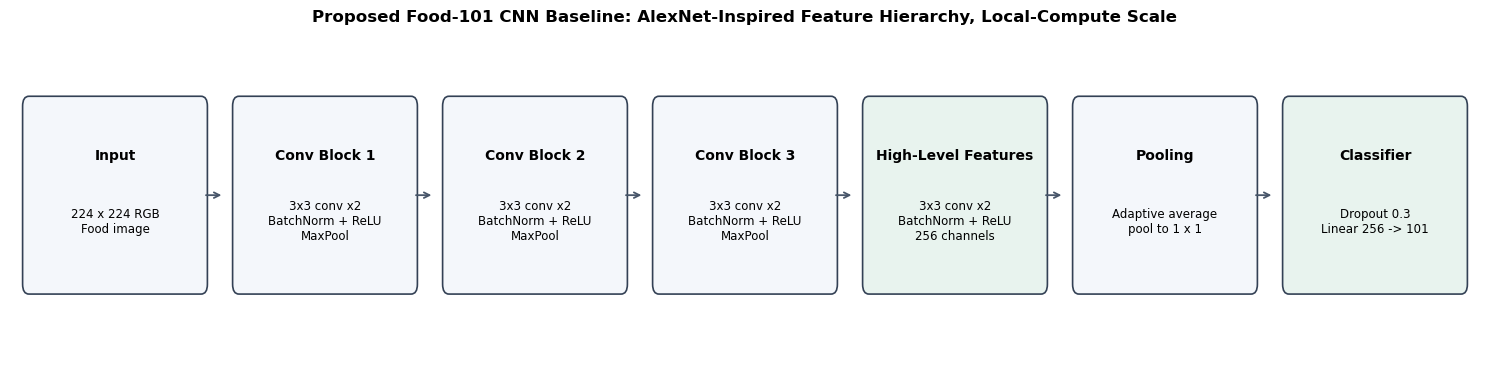

In [7]:
architecture_blocks = [
    ("Input", "224 x 224 RGB\nFood image"),
    ("Conv Block 1", "3x3 conv x2\nBatchNorm + ReLU\nMaxPool"),
    ("Conv Block 2", "3x3 conv x2\nBatchNorm + ReLU\nMaxPool"),
    ("Conv Block 3", "3x3 conv x2\nBatchNorm + ReLU\nMaxPool"),
    ("High-Level Features", "3x3 conv x2\nBatchNorm + ReLU\n256 channels"),
    ("Pooling", "Adaptive average\npool to 1 x 1"),
    ("Classifier", "Dropout 0.3\nLinear 256 -> 101"),
]

fig, ax = plt.subplots(figsize=(15, 3.8))
ax.set_xlim(0, len(architecture_blocks))
ax.set_ylim(0, 1)
ax.axis("off")

for index, (title, description) in enumerate(architecture_blocks):
    x = index + 0.08
    width = 0.84
    patch = FancyBboxPatch(
        (x, 0.22),
        width,
        0.56,
        boxstyle="round,pad=0.02,rounding_size=0.03",
        facecolor="#f4f7fb" if index not in {4, 6} else "#e8f3ee",
        edgecolor="#334155",
        linewidth=1.2,
    )
    ax.add_patch(patch)
    ax.text(x + width / 2, 0.62, title, ha="center", va="center", fontsize=10, weight="bold")
    ax.text(x + width / 2, 0.42, description, ha="center", va="center", fontsize=8.5)
    if index < len(architecture_blocks) - 1:
        ax.annotate(
            "",
            xy=(index + 1.02, 0.5),
            xytext=(index + 0.92, 0.5),
            arrowprops={"arrowstyle": "->", "lw": 1.3, "color": "#475569"},
        )

ax.set_title("Proposed Food-101 CNN Baseline: AlexNet-Inspired Feature Hierarchy, Local-Compute Scale", fontsize=12, weight="bold")
plt.tight_layout()
plt.show()

In [8]:
baseline_model = build_model(
    "baseline_cnn",
    num_classes=int(config["model"]["num_classes"]),
    pretrained=False,
    dropout=float(config["model"]["dropout"]),
)
baseline_model.eval()
with torch.no_grad():
    baseline_logits = baseline_model(torch.randn(2, 3, 64, 64))

tuple(baseline_logits.shape)

(2, 101)

## 8. Transfer Learning Design

The transfer-learning stage compares EfficientNet-B0, ResNet-50, and ConvNeXt-Tiny. Classifier heads are replaced for the configured number of Food-101 classes, and freezing utilities support staged fine-tuning. EfficientNet-B0 is emphasized for constrained local runs, not treated as the automatic final model.

### Fine-Tuning Backbone Differences

EfficientNet-B0, ResNet-50, and ConvNeXt-Tiny are not interchangeable defaults; they trade accuracy, memory, and optimization behavior differently.

**EfficientNet-B0** uses compound scaling and mobile inverted bottleneck blocks, so it gives a strong pretrained baseline with fewer parameters and usually allows larger local batch sizes. 

**ResNet-50** uses residual bottleneck blocks, which make deep optimization stable and robust, but the model is heavier. 

**ConvNeXt-Tiny** modernizes convolutional networks with a patch-like stem, depthwise large-kernel convolutions, LayerNorm, and GELU-style blocks; it can be more accurate, but it is the most demanding option here. 

For the provided local compute environment, EfficientNet-B0 is the most practical transfer-learning candidate because it balances pretrained representation quality with smaller memory and faster iteration, while ResNet-50 and ConvNeXt-Tiny are useful comparison models when compute budget permits.

In [9]:
transfer_smoke_rows = []
for transfer_name in ["efficientnet_b0", "resnet50", "convnext_tiny"]:
    transfer_config = load_config(PROJECT_ROOT / "configs" / f"{transfer_name}.yaml", project_root=PROJECT_ROOT)
    transfer_smoke = build_model(
        transfer_name,
        num_classes=int(transfer_config["model"]["num_classes"]),
        pretrained=False,
        dropout=float(transfer_config["model"].get("dropout", 0.3)),
        freeze_backbone_initially=bool(transfer_config["model"].get("freeze_backbone_initially", True)),
    )
    transfer_smoke_rows.append(
        {
            "model": transfer_name,
            "total_parameters": sum(param.numel() for param in transfer_smoke.parameters()),
            "initial_trainable_parameters": sum(param.numel() for param in transfer_smoke.parameters() if param.requires_grad),
        }
    )

pd.DataFrame(transfer_smoke_rows)

,model,total_parameters,initial_trainable_parameters
0,efficientnet_b0,4136929,129381
1,resnet50,23714981,206949
2,convnext_tiny,27897797,79205


## 9. Training Strategy

Training uses Adam, label smoothing, ReduceLROnPlateau, TensorBoard logging, early stopping, and checkpointing by validation top-5 accuracy. The smoke cell below exercises the training loop on synthetic tensors only.

In [10]:
smoke_model = torch.nn.Sequential(torch.nn.Flatten(), torch.nn.Linear(3 * 8 * 8, 5))
images = torch.randn(8, 3, 8, 8)
labels = torch.arange(8) % 5
loader = DataLoader(TensorDataset(images, labels), batch_size=4)
criterion = build_classification_loss(label_smoothing=0.1)
optimizer = build_optimizer(smoke_model, lr=1e-3)

train_metrics = train_one_epoch(smoke_model, loader, criterion, optimizer, "cpu", top_k=(1, 5), max_batches=1)
val_metrics = validate_one_epoch(smoke_model, loader, criterion, "cpu", top_k=(1, 5), max_batches=1)
pd.DataFrame([{"split": "train", **train_metrics.__dict__}, {"split": "validation", **val_metrics.__dict__}])

,split,loss,top1,top5,samples
0,train,1.708450,0.25,1.0,4
1,validation,1.571016,0.25,1.0,4


CLI cells below are guarded by `RUN_TRAINING` and `RUN_FINAL_EVAL`. They execute the same scripts documented in the README, so notebook results remain reproducible from the command line.

In [11]:
def run_cli(command: list[str | Path]) -> subprocess.CompletedProcess:
    command = [str(part) for part in command]
    env = {**os.environ, "KMP_DUPLICATE_LIB_OK": "TRUE"}
    print("$", " ".join(command))
    return subprocess.run(command, cwd=PROJECT_ROOT, env=env, check=True, text=True)


def train_command(config_path: str, *, epochs: int | None = None, max_batches: int | None = None) -> list[str]:
    command = [sys.executable, "scripts/train.py", "--config", config_path, "--index-csv", "data/reports/dataset_index.csv", "--log-level", "INFO"]
    if epochs is not None:
        command.extend(["--epochs", str(epochs)])
    if max_batches is not None:
        command.extend(["--max-batches", str(max_batches)])
    return command


def evaluate_command(config_path: str, checkpoint_path: str | Path) -> list[str]:
    return [
        sys.executable,
        "scripts/evaluate.py",
        "--config",
        config_path,
        "--checkpoint",
        str(checkpoint_path),
        "--index-csv",
        "data/reports/dataset_index.csv",
        "--split",
        "test",
    ]


def model_config_path(model_name: str) -> str:
    config_path = PROJECT_ROOT / "configs" / f"{model_name}.yaml"
    if not config_path.is_file():
        raise FileNotFoundError(f"No config found for model {model_name!r}: {config_path}")
    return config_path.relative_to(PROJECT_ROOT).as_posix()


def manifest_config_path(manifest: dict) -> str:
    return model_config_path(str(manifest.get("model_name") or config["model"]["name"]))


def resolved_manifest(manifest: dict | None) -> dict | None:
    if manifest is None:
        return None
    return manifest_with_resolved_artifacts(manifest, project_root=PROJECT_ROOT)


def resolved_latest_run_for_model(model_name: str) -> dict | None:
    return resolved_manifest(latest_run_for_model(PROJECT_ROOT, model_name))


def artifact_path(manifest: dict | None, artifact_name: str) -> Path | None:
    if manifest is None:
        return None
    return resolve_manifest_artifact(manifest, artifact_name, project_root=PROJECT_ROOT)

## 10. Experiment 1: Small Subset Sanity Check

The first run should use a small class subset and one or two epochs. The objective is not accuracy; it is to verify indexing, transforms, loss, metrics, checkpointing, and logging.

### Sanity Schedule

Run `baseline_cnn` for one epoch and a few mini-batches. This is a pipeline test, not a performance result.

In [12]:
sanity_command = train_command("configs/baseline_cnn.yaml", epochs=1, max_batches=5)
if RUN_TRAINING:
    run_cli(sanity_command)
else:
    print(" ".join(sanity_command))

/Users/alex/miniconda3/envs/food101-cnn/bin/python scripts/train.py --config configs/baseline_cnn.yaml --index-csv data/reports/dataset_index.csv --log-level INFO --epochs 1 --max-batches 5


## 11. Experiment 2: Baseline CNN

The CNN-from-scratch baseline should be trained after the sanity check. It establishes a pedagogical reference for how much transfer learning improves convergence and accuracy.

### Baseline Training Schedule

Train `baseline_cnn` locally for a feasible full baseline. Start with 10 epochs, inspect validation top-5, then increase only if loss is still improving and memory remains stable.

In [13]:
baseline_command = train_command("configs/baseline_cnn.yaml", epochs=10)
if RUN_TRAINING:
    run_cli(baseline_command)
else:
    print(" ".join(baseline_command))

/Users/alex/miniconda3/envs/food101-cnn/bin/python scripts/train.py --config configs/baseline_cnn.yaml --index-csv data/reports/dataset_index.csv --log-level INFO --epochs 10


## 12. Experiment 3: EfficientNet-B0 Transfer Learning

The EfficientNet-B0 run should train the classifier head first with the backbone frozen, then partially unfreeze the upper blocks and fine-tune using a lower learning rate.

### EfficientNet-B0 Candidate

EfficientNet-B0 is included as a practical local candidate because it usually offers the best balance between pretrained feature quality, memory use, and iteration speed. Its artifacts are handled through the same run layout as the other models, and final selection remains metric-driven.

In [14]:
efficientnet_latest = resolved_latest_run_for_model("efficientnet_b0")
if efficientnet_latest:
    display(pd.DataFrame([manifest_to_comparison_row(efficientnet_latest)]))
else:
    efficientnet_command = train_command("configs/efficientnet_b0.yaml")
    if RUN_TRAINING:
        run_cli(efficientnet_command)
    else:
        print("No EfficientNet-B0 run found. Command:", " ".join(efficientnet_command))

,model,version,trained_at,checkpoint,top1,top5,macro_f1,ece,latency_ms,params,notes
0,efficientnet_b0,v1,20260602-0040,/Users/alex/Documents/IA_aero_upm/food101-cnn/...,0.584277,0.820475,0.577144,0.159771,8.587793,4136929,training completed via scripts/train.py; evalu...


## 13. Experiment 4: Backbone Comparison

Backbone comparison should use the same official split policy, preprocessing, metrics, and evaluation code for EfficientNet-B0, ResNet-50, and ConvNeXt-Tiny.

In [15]:
remaining_comparison_commands = {
    "resnet50": train_command("configs/resnet50.yaml", epochs=5),
    "convnext_tiny": train_command("configs/convnext_tiny.yaml", epochs=5),
}
if RUN_TRAINING:
    for command in remaining_comparison_commands.values():
        run_cli(command)
else:
    for model_name, command in remaining_comparison_commands.items():
        print(model_name, "->", " ".join(command))

manifests = [resolved_manifest(item) for item in list_run_manifests(PROJECT_ROOT)]
comparison_rows = [manifest_to_comparison_row(item) for item in manifests]
comparison_table = pd.DataFrame(comparison_rows, columns=["model", "version", "trained_at", "checkpoint", "top1", "top5", "macro_f1", "ece", "latency_ms", "params", "notes"])
comparison_table

resnet50 -> /Users/alex/miniconda3/envs/food101-cnn/bin/python scripts/train.py --config configs/resnet50.yaml --index-csv data/reports/dataset_index.csv --log-level INFO --epochs 5
convnext_tiny -> /Users/alex/miniconda3/envs/food101-cnn/bin/python scripts/train.py --config configs/convnext_tiny.yaml --index-csv data/reports/dataset_index.csv --log-level INFO --epochs 5


,model,version,trained_at,checkpoint,top1,top5,macro_f1,ece,latency_ms,params,notes
0,convnext_tiny,v1,20260602-1258,/Users/alex/Documents/IA_aero_upm/food101-cnn/...,0.743089,0.926574,0.741738,0.184742,5.679270,27897797.0,training completed via scripts/train.py; evalu...
1,resnet50,v1,20260602-0657,/Users/alex/Documents/IA_aero_upm/food101-cnn/...,0.659723,0.876594,0.655682,0.194691,6.298052,23714981.0,training completed via scripts/train.py; evalu...
2,efficientnet_b0,v1,20260602-0040,/Users/alex/Documents/IA_aero_upm/food101-cnn/...,0.584277,0.820475,0.577144,0.159771,8.587793,4136929.0,training completed via scripts/train.py; evalu...
3,baseline_cnn,v1,20260602-0000,/Users/alex/Documents/IA_aero_upm/food101-cnn/...,0.659327,0.888752,0.661621,0.134669,1.139143,1199173.0,training completed via scripts/train.py; evalu...
4,efficientnet_b0,v1,20260601-1625,/Users/alex/Documents/IA_aero_upm/food101-cnn/...,0.550653,0.797386,0.539075,0.101495,6.969952,NaN,migrated from legacy outputs/checkpoints and o...


In [ ]:
MODEL_DISPLAY_NAMES = {
    "baseline_cnn": "Baseline CNN",
    "baseline_cnn_local": "Simple CNN",
    "efficientnet_b0": "EfficientNet-B0",
    "resnet50": "ResNet-50",
    "convnext_tiny": "ConvNeXt-Tiny",
}
MODEL_STRUCTURES = {
    "baseline_cnn": "Stacked two-conv Conv-BN-ReLU blocks + late 256-channel refinements + adaptive pooling",
    "baseline_cnn_local": "Simpler single-conv blocks with 16/32/64 channels + adaptive pooling",
    "efficientnet_b0": "Stem + MBConv stages + 1x1 head + classifier",
    "resnet50": "Stem + residual bottleneck stages + global pool + fc",
    "convnext_tiny": "Patch stem + ConvNeXt depthwise stages + LayerNorm head",
}


def load_model_config(model_name: str) -> dict:
    return load_config(PROJECT_ROOT / "configs" / f"{model_name}.yaml", project_root=PROJECT_ROOT)


def build_uninitialized_model_for_summary(model_name: str, model_config: dict) -> torch.nn.Module:
    model_settings = model_config["model"]
    return build_model(
        model_name,
        num_classes=int(model_settings["num_classes"]),
        pretrained=False,
        dropout=float(model_settings.get("dropout", 0.3)),
        freeze_backbone_initially=bool(model_settings.get("freeze_backbone_initially", False)),
    )


def parameter_count(model: torch.nn.Module, *, trainable_only: bool = False) -> int:
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if not trainable_only or parameter.requires_grad
    )


def parameterized_layer_count(model: torch.nn.Module) -> int:
    return sum(1 for module in model.modules() if next(module.parameters(recurse=False), None) is not None)


def checkpoint_size_mb(path: Path | None) -> float | None:
    if path is None or not path.is_file():
        return None
    return round(path.stat().st_size / 1024**2, 2)


model_comparison_rows = []
for model_name in SUPPORTED_MODELS:
    model_config = load_model_config(model_name)
    model = build_uninitialized_model_for_summary(model_name, model_config)
    manifest = resolved_latest_run_for_model(model_name)
    checkpoint = artifact_path(manifest, "checkpoint")
    metrics = manifest.get("metrics", {}) if manifest else {}
    model_comparison_rows.append(
        {
            "model": MODEL_DISPLAY_NAMES.get(model_name, model_name),
            "model_key": model_name,
            "structure": MODEL_STRUCTURES[model_name],
            "pretrained": bool(model_config["model"].get("pretrained", False)),
            "initial_freeze": bool(model_config["model"].get("freeze_backbone_initially", False)),
            "batch_size": int(model_config["training"]["batch_size"]),
            "total_parameters_m": round(parameter_count(model) / 1_000_000, 2),
            "initial_trainable_parameters_m": round(parameter_count(model, trainable_only=True) / 1_000_000, 2),
            "parameterized_layers": parameterized_layer_count(model),
            "checkpoint_size_mb": checkpoint_size_mb(checkpoint),
            "top1": metrics.get("top1"),
            "top5": metrics.get("top5"),
            "macro_f1": metrics.get("macro_f1"),
        }
    )

model_comparison = pd.DataFrame(model_comparison_rows)
model_comparison.sort_values(["top5", "macro_f1"], ascending=False, na_position="last")


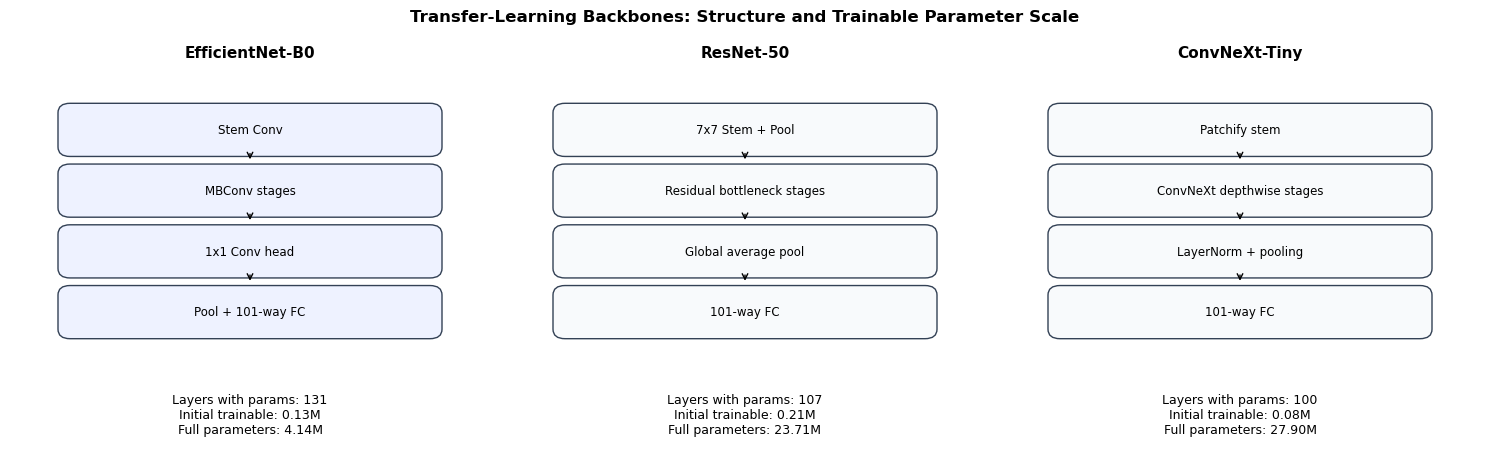

In [17]:
transfer_structure_steps = {
    "efficientnet_b0": ["Stem Conv", "MBConv stages", "1x1 Conv head", "Pool + 101-way FC"],
    "resnet50": ["7x7 Stem + Pool", "Residual bottleneck stages", "Global average pool", "101-way FC"],
    "convnext_tiny": ["Patchify stem", "ConvNeXt depthwise stages", "LayerNorm + pooling", "101-way FC"],
}

transfer_models = ["efficientnet_b0", "resnet50", "convnext_tiny"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)

for ax, model_name in zip(axes, transfer_models):
    row = model_comparison.loc[model_comparison["model_key"] == model_name].iloc[0]
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title(MODEL_DISPLAY_NAMES[model_name], fontsize=11, weight="bold")

    steps = transfer_structure_steps[model_name]
    for index, step in enumerate(steps):
        y = 0.78 - index * 0.16
        patch = FancyBboxPatch(
            (0.12, y),
            0.76,
            0.1,
            boxstyle="round,pad=0.02,rounding_size=0.025",
            facecolor="#eef2ff" if model_name == "efficientnet_b0" else "#f8fafc",
            edgecolor="#334155",
            linewidth=1.0,
        )
        ax.add_patch(patch)
        ax.text(0.5, y + 0.05, step, ha="center", va="center", fontsize=8.5)
        if index < len(steps) - 1:
            ax.annotate("", xy=(0.5, y - 0.035), xytext=(0.5, y - 0.005), arrowprops={"arrowstyle": "->", "lw": 1.0})

    summary = (
        f"Layers with params: {int(row['parameterized_layers'])}\n"
        f"Initial trainable: {row['initial_trainable_parameters_m']:.2f}M\n"
        f"Full parameters: {row['total_parameters_m']:.2f}M"
    )
    ax.text(0.5, 0.08, summary, ha="center", va="center", fontsize=9)

fig.suptitle("Transfer-Learning Backbones: Structure and Trainable Parameter Scale", fontsize=12, weight="bold")
plt.tight_layout()
plt.show()

The table and figure separate suitability from final score.

**ConvNeXt-Tiny** can be the best-scoring local run, but it is also larger and more expensive. 

**EfficientNet-B0** is highlighted as the most suitable model for constrained local experimentation because it keeps transfer learning practical: fewer parameters, smaller checkpoint footprint, and less pressure on batch size and memory.

**ResNet-50** is a useful middle comparison because residual bottlenecks are robust and widely studied, but it does not offer the same parameter efficiency as EfficientNet-B0.

In conclusion, even if best results are obtained with the ConVNeXt-Tiny model, due to computational constraints, the EfficientNet-B0 offers a good trade-off between efficiency and average class accuracy.

## 14. Final 101-Class Model

The final selected model should be trained on all 101 classes using the official training split plus internal validation. The official test split is used only once for final evaluation.

### Candidate Selection

The final selected model is chosen after model choices are frozen, using top-5 accuracy first and macro F1 second. Official test metrics are used for the course comparison table, not for iterative hyperparameter tuning.

In [18]:
candidate_manifests = [resolved_manifest(item) for item in list_run_manifests(PROJECT_ROOT)]
best_manifest = select_best_run(candidate_manifests)
if best_manifest:
    display(pd.DataFrame([manifest_to_comparison_row(best_manifest)]))
else:
    print("No completed run manifests are available yet.")

,model,version,trained_at,checkpoint,top1,top5,macro_f1,ece,latency_ms,params,notes
0,convnext_tiny,v1,20260602-1258,/Users/alex/Documents/IA_aero_upm/food101-cnn/...,0.743089,0.926574,0.741738,0.184742,5.67927,27897797,training completed via scripts/train.py; evalu...


## 15. Evaluation

Final evaluation reports top-1, top-5, macro F1, per-class accuracy, confusion matrix, and latency. The cell below reads generated report artifacts when they exist.

In [19]:
evaluation_manifest = best_manifest or resolved_latest_run_for_model(REPORT_REFERENCE_MODEL)
metrics_json = artifact_path(evaluation_manifest, "metrics_json")
checkpoint_path = artifact_path(evaluation_manifest, "checkpoint")

if metrics_json and metrics_json.is_file():
    metrics_payload = json.loads(metrics_json.read_text(encoding="utf-8"))
    display(pd.DataFrame([metrics_payload]))
elif RUN_FINAL_EVAL and evaluation_manifest and checkpoint_path and checkpoint_path.is_file():
    run_cli(evaluate_command(manifest_config_path(evaluation_manifest), checkpoint_path))
else:
    print("No local evaluation report or checkpoint found for the selected model run.")

,top1,top5,macro_f1,per_class_accuracy,per_class_support,loss,samples,split,top_k,ece,latency
0,0.743089,0.926574,0.741738,"[0.4, 0.732, 0.78, 0.752, 0.676, 0.616, 0.824,...","[250, 250, 250, 250, 250, 250, 250, 250, 250, ...",1.747239,25250,test,5,0.184742,"{'mean_ms': 5.67926969997643, 'median_ms': 5.5..."


## 16. Calibration Analysis

Calibration checks whether confidence values are meaningful. The project reports expected calibration error and confidence-bin statistics from validation or test logits.

In [20]:
demo_logits = torch.tensor([[3.0, 0.5, 0.1], [0.2, 2.0, 0.1], [0.2, 2.0, 0.1]])
demo_targets = torch.tensor([0, 1, 2])
demo_metrics = classification_metrics_from_logits(demo_logits, demo_targets, num_classes=3, top_k=3)
demo_calibration = calibration_report(demo_logits, demo_targets, num_bins=5)
{
    "top1": demo_metrics.top1,
    "top3": demo_metrics.top5,
    "macro_f1": demo_metrics.macro_f1,
    "ece": demo_calibration.ece,
}

{'top1': 0.6666666865348816,
 'top3': 1.0,
 'macro_f1': 0.5555555555555555,
 'ece': 0.21388067801793414}

## 17. Misclassification Analysis

Misclassification analysis records the true label, top-1 prediction, top-k labels, probabilities, image path, and confidence. High-confidence errors and low-confidence ambiguous cases should be inspected separately.

In [21]:
demo_errors = collect_misclassifications(
    demo_logits,
    demo_targets,
    class_names=["apple_pie", "pizza", "ramen"],
    image_paths=["demo_0.jpg", "demo_1.jpg", "demo_2.jpg"],
    top_k=3,
)
pd.DataFrame([record.__dict__ for record in demo_errors])

,image_path,true_label,predicted_label,confidence,top_k_labels,top_k_probabilities
0,demo_2.jpg,ramen,pizza,0.760533,"[pizza, apple_pie, ramen]","[0.7605329155921936, 0.1257152557373047, 0.113..."


## 18. Post-processing and Debugging Analysis

This section materializes the debug and evaluation artifacts used for the final discussion. The notebook calls the reusable post-processing CLI, then displays the generated figures and tables inline so the report does not depend on hidden local files. Top-5 accuracy is emphasized because Food-101 contains visually similar dishes; a correct class in the top five is often more useful than a single brittle top-1 label when predictions are returned to a user.


In [22]:
POSTPROCESS_OUTPUT_DIR = PROJECT_ROOT / "outputs"
POSTPROCESS_REPORTS_DIR = POSTPROCESS_OUTPUT_DIR / "reports"
POSTPROCESS_FIGURES_DIR = POSTPROCESS_OUTPUT_DIR / "figures"
POSTPROCESS_REPORTS_DIR.mkdir(parents=True, exist_ok=True)
POSTPROCESS_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

postprocess_manifest = best_manifest or resolved_latest_run_for_model(REPORT_REFERENCE_MODEL)
postprocess_config_path = (
    manifest_config_path(postprocess_manifest)
    if postprocess_manifest
    else PROJECT_CONFIG_PATH.relative_to(PROJECT_ROOT).as_posix()
)

postprocess_command = [
    sys.executable,
    "scripts/postprocess_runs.py",
    "--config",
    postprocess_config_path,
    "--log-dir",
    "outputs/runs",
    "--output-dir",
    "outputs",
]

for option, artifact_name in [
    ("--predictions", "predictions_csv"),
    ("--confusion-csv", "confusion_csv"),
    ("--misclassified-csv", "misclassified_csv"),
    ("--calibration-json", "calibration_json"),
]:
    artifact = artifact_path(postprocess_manifest, artifact_name)
    if artifact and artifact.is_file():
        postprocess_command.extend([option, artifact])

if RUN_POSTPROCESSING:
    run_cli(postprocess_command)
else:
    print("Skipped post-processing. Enable RUN_POSTPROCESSING to regenerate report artifacts.")


$ /Users/alex/miniconda3/envs/food101-cnn/bin/python scripts/postprocess_runs.py --config configs/convnext_tiny.yaml --log-dir outputs/runs --output-dir outputs --confusion-csv /Users/alex/Documents/IA_aero_upm/food101-cnn/outputs/runs/convnext_tiny_20260602-1258_v1/reports/confusion_matrix.csv --misclassified-csv /Users/alex/Documents/IA_aero_upm/food101-cnn/outputs/runs/convnext_tiny_20260602-1258_v1/reports/convnext_tiny_20260602-1258_v1_misclassified.csv --calibration-json /Users/alex/Documents/IA_aero_upm/food101-cnn/outputs/runs/convnext_tiny_20260602-1258_v1/reports/calibration_report.json
Generated post-processing artifacts:
- /Users/alex/Documents/IA_aero_upm/food101-cnn/outputs/reports/tensorboard_scalars.csv
- /Users/alex/Documents/IA_aero_upm/food101-cnn/outputs/figures/training_curves/loss_curves.png
- /Users/alex/Documents/IA_aero_upm/food101-cnn/outputs/figures/training_curves/top1_accuracy_curves.png
- /Users/alex/Documents/IA_aero_upm/food101-cnn/outputs/figures/traini

In [23]:
def relative_display_path(path: Path) -> str:
    try:
        return path.relative_to(PROJECT_ROOT).as_posix()
    except ValueError:
        return str(path)


def display_png(path: str | Path, *, width: int = 900) -> None:
    resolved = Path(path)
    if not resolved.is_absolute():
        resolved = PROJECT_ROOT / resolved
    if resolved.is_file():
        display(DisplayImage(filename=str(resolved), width=width))
    else:
        print(f"Missing figure: {relative_display_path(resolved)}")


def display_csv(path: str | Path, *, rows: int = 10) -> pd.DataFrame | None:
    resolved = Path(path)
    if not resolved.is_absolute():
        resolved = PROJECT_ROOT / resolved
    if not resolved.is_file():
        print(f"Missing table: {relative_display_path(resolved)}")
        return None
    frame = pd.read_csv(resolved)
    display(frame.head(rows))
    return frame


def load_report_json(path: str | Path) -> dict:
    resolved = Path(path)
    if not resolved.is_absolute():
        resolved = PROJECT_ROOT / resolved
    if not resolved.is_file():
        print(f"Missing JSON report: {relative_display_path(resolved)}")
        return {}
    return json.loads(resolved.read_text(encoding="utf-8"))


### Training Curves from TensorBoard Logs

Training and validation curves are the first debugging signal. A widening train/validation gap suggests overfitting, while flat high losses on both splits suggest underfitting or a data/preprocessing issue. The plots below are extracted from TensorBoard event files rather than manually re-entered metrics.


**loss_curves.png**

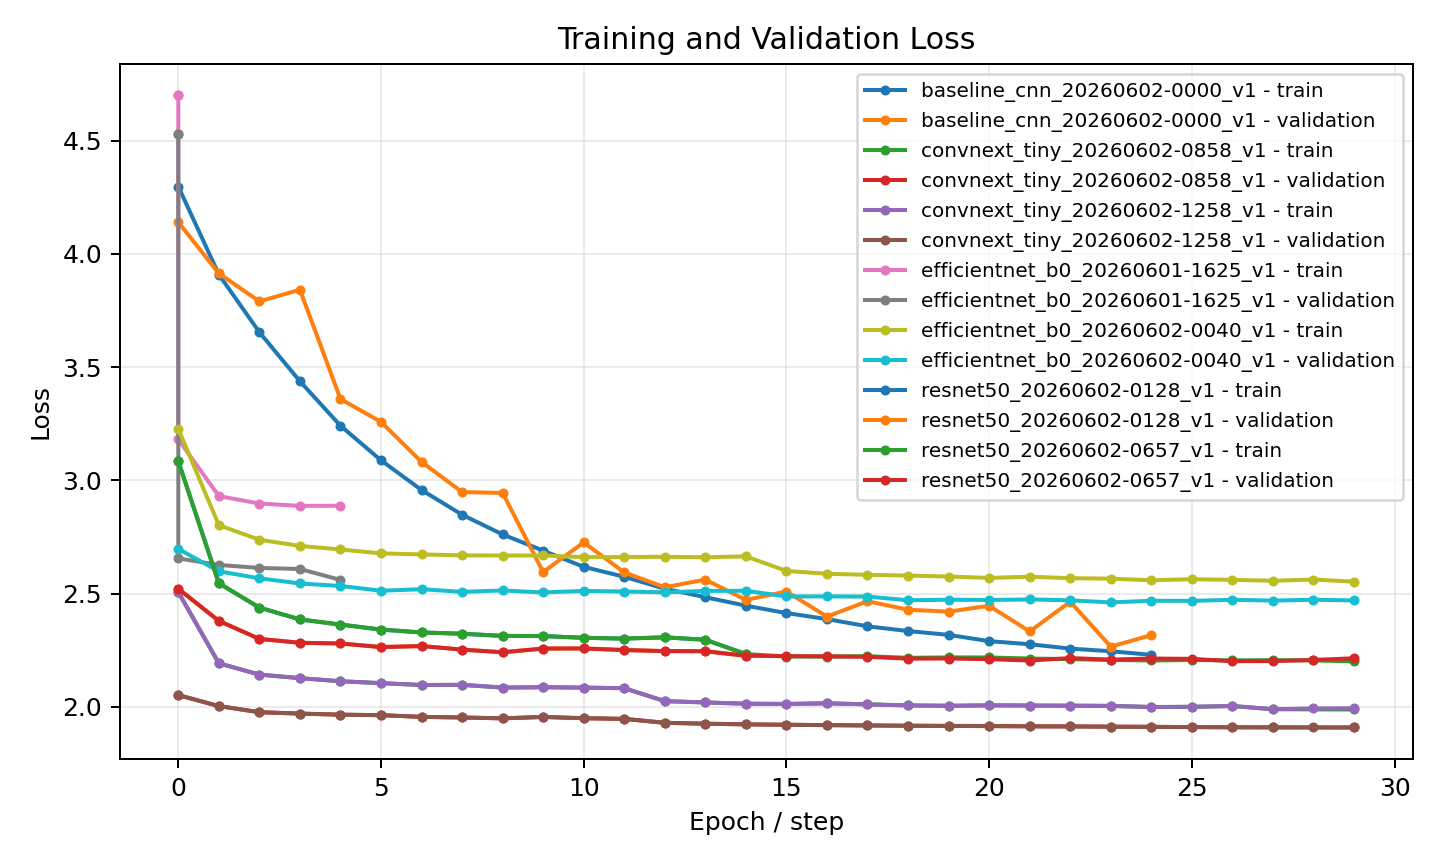

**top1_accuracy_curves.png**

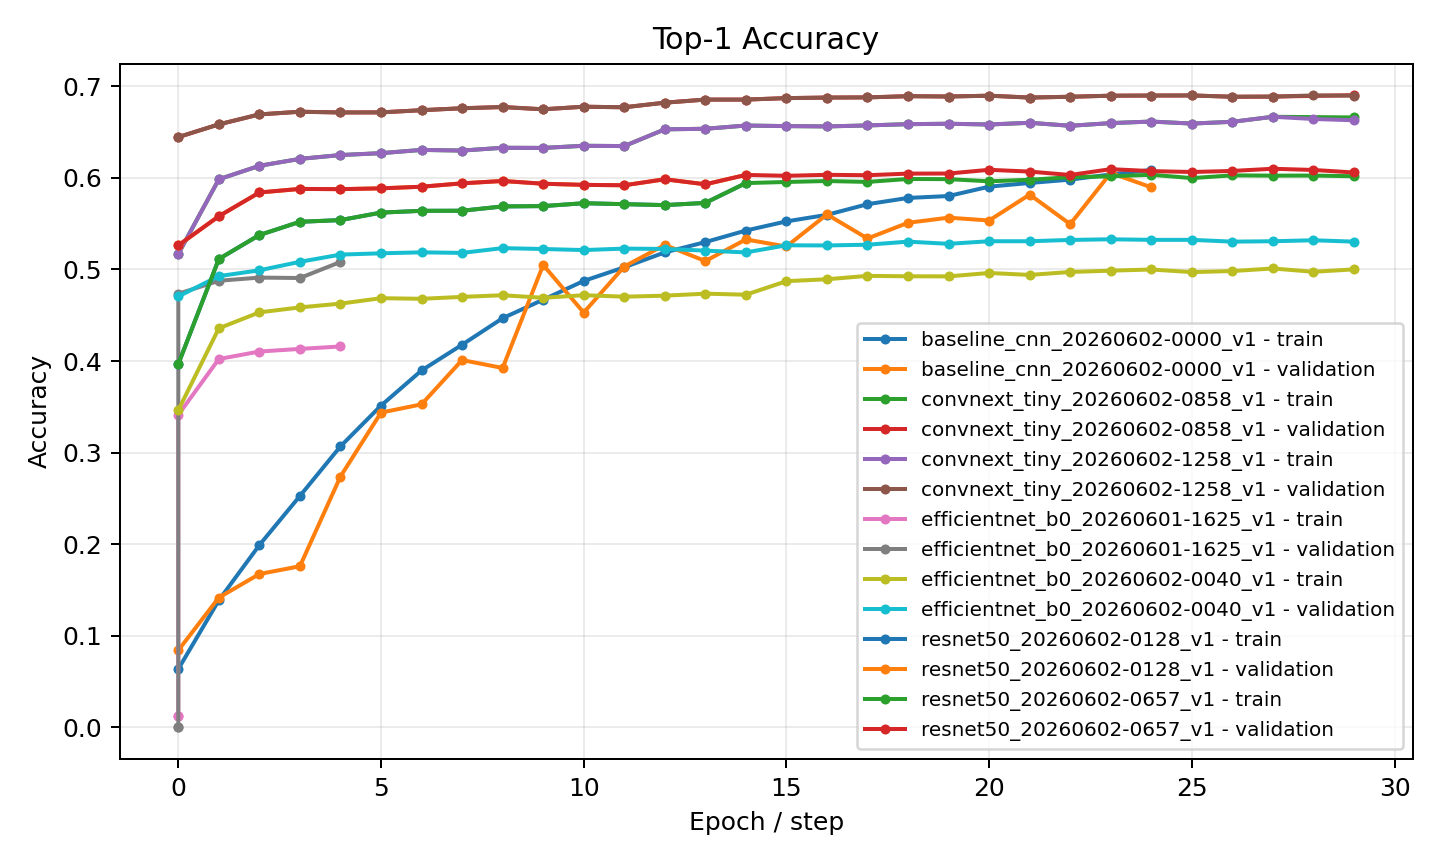

**top5_accuracy_curves.png**

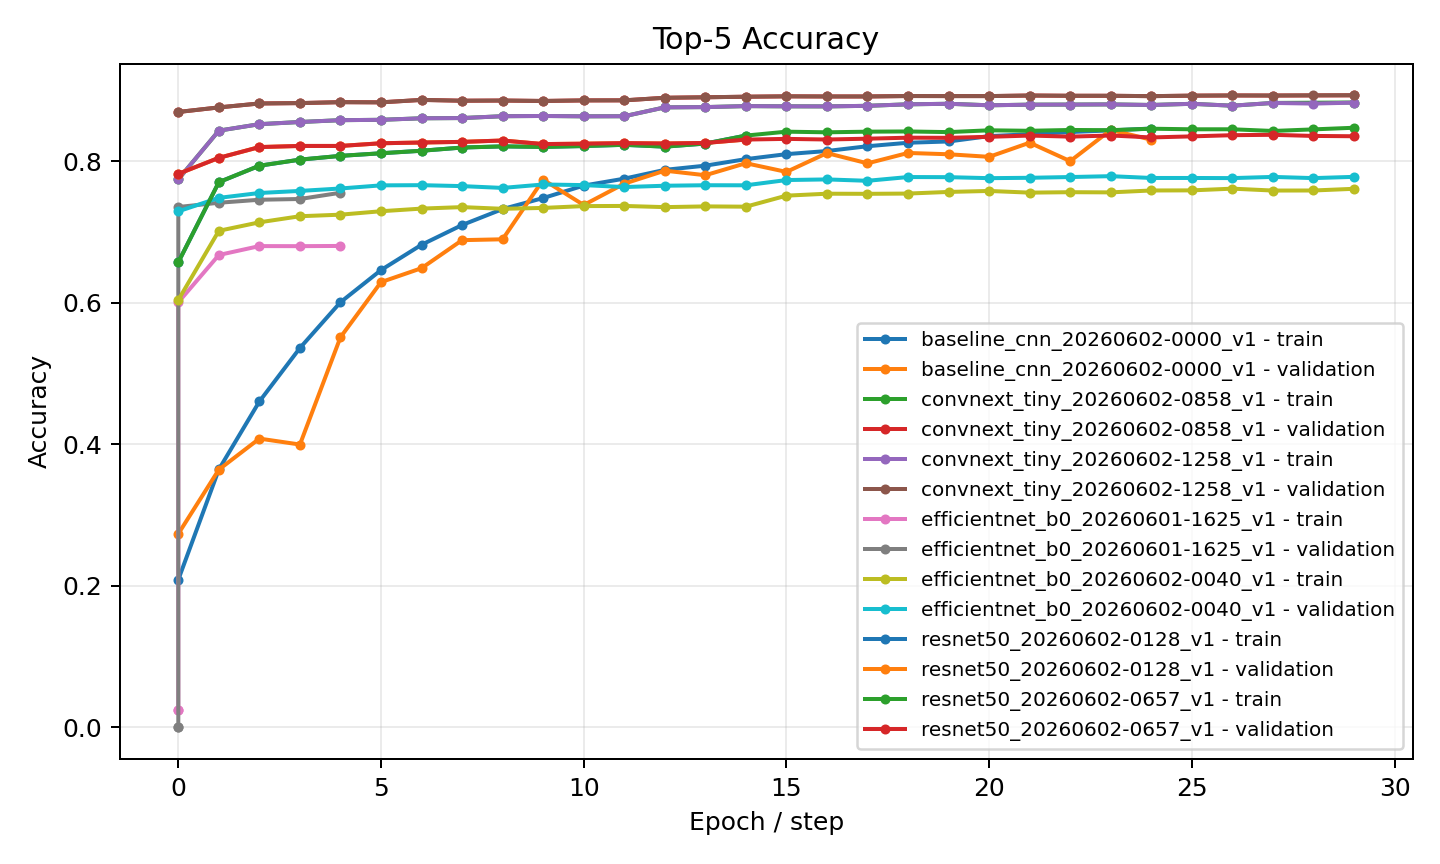

**macro_f1_curves.png**

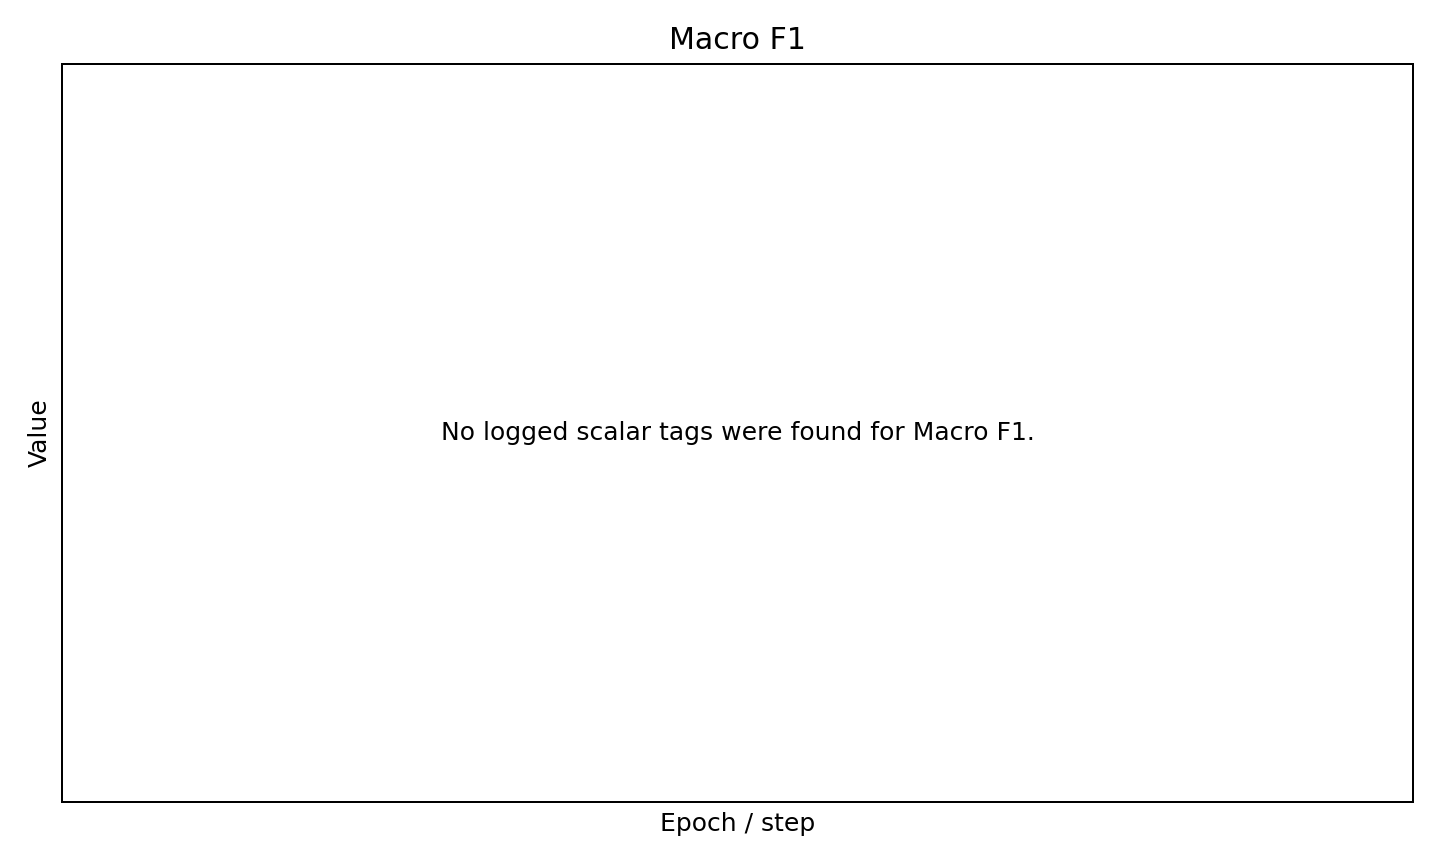

**learning_rate_curves.png**

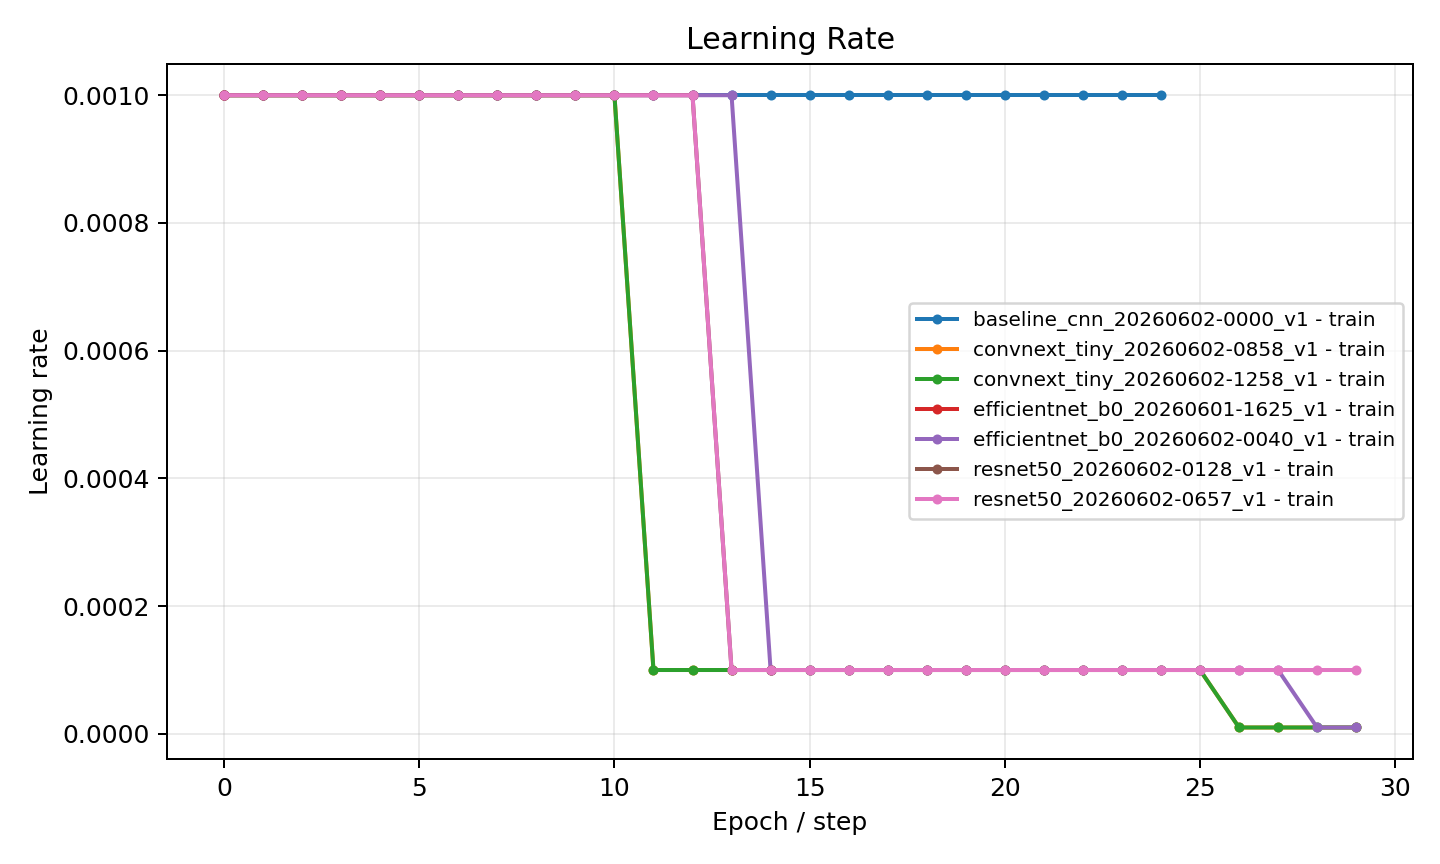

**all_scalar_metrics_overview.png**

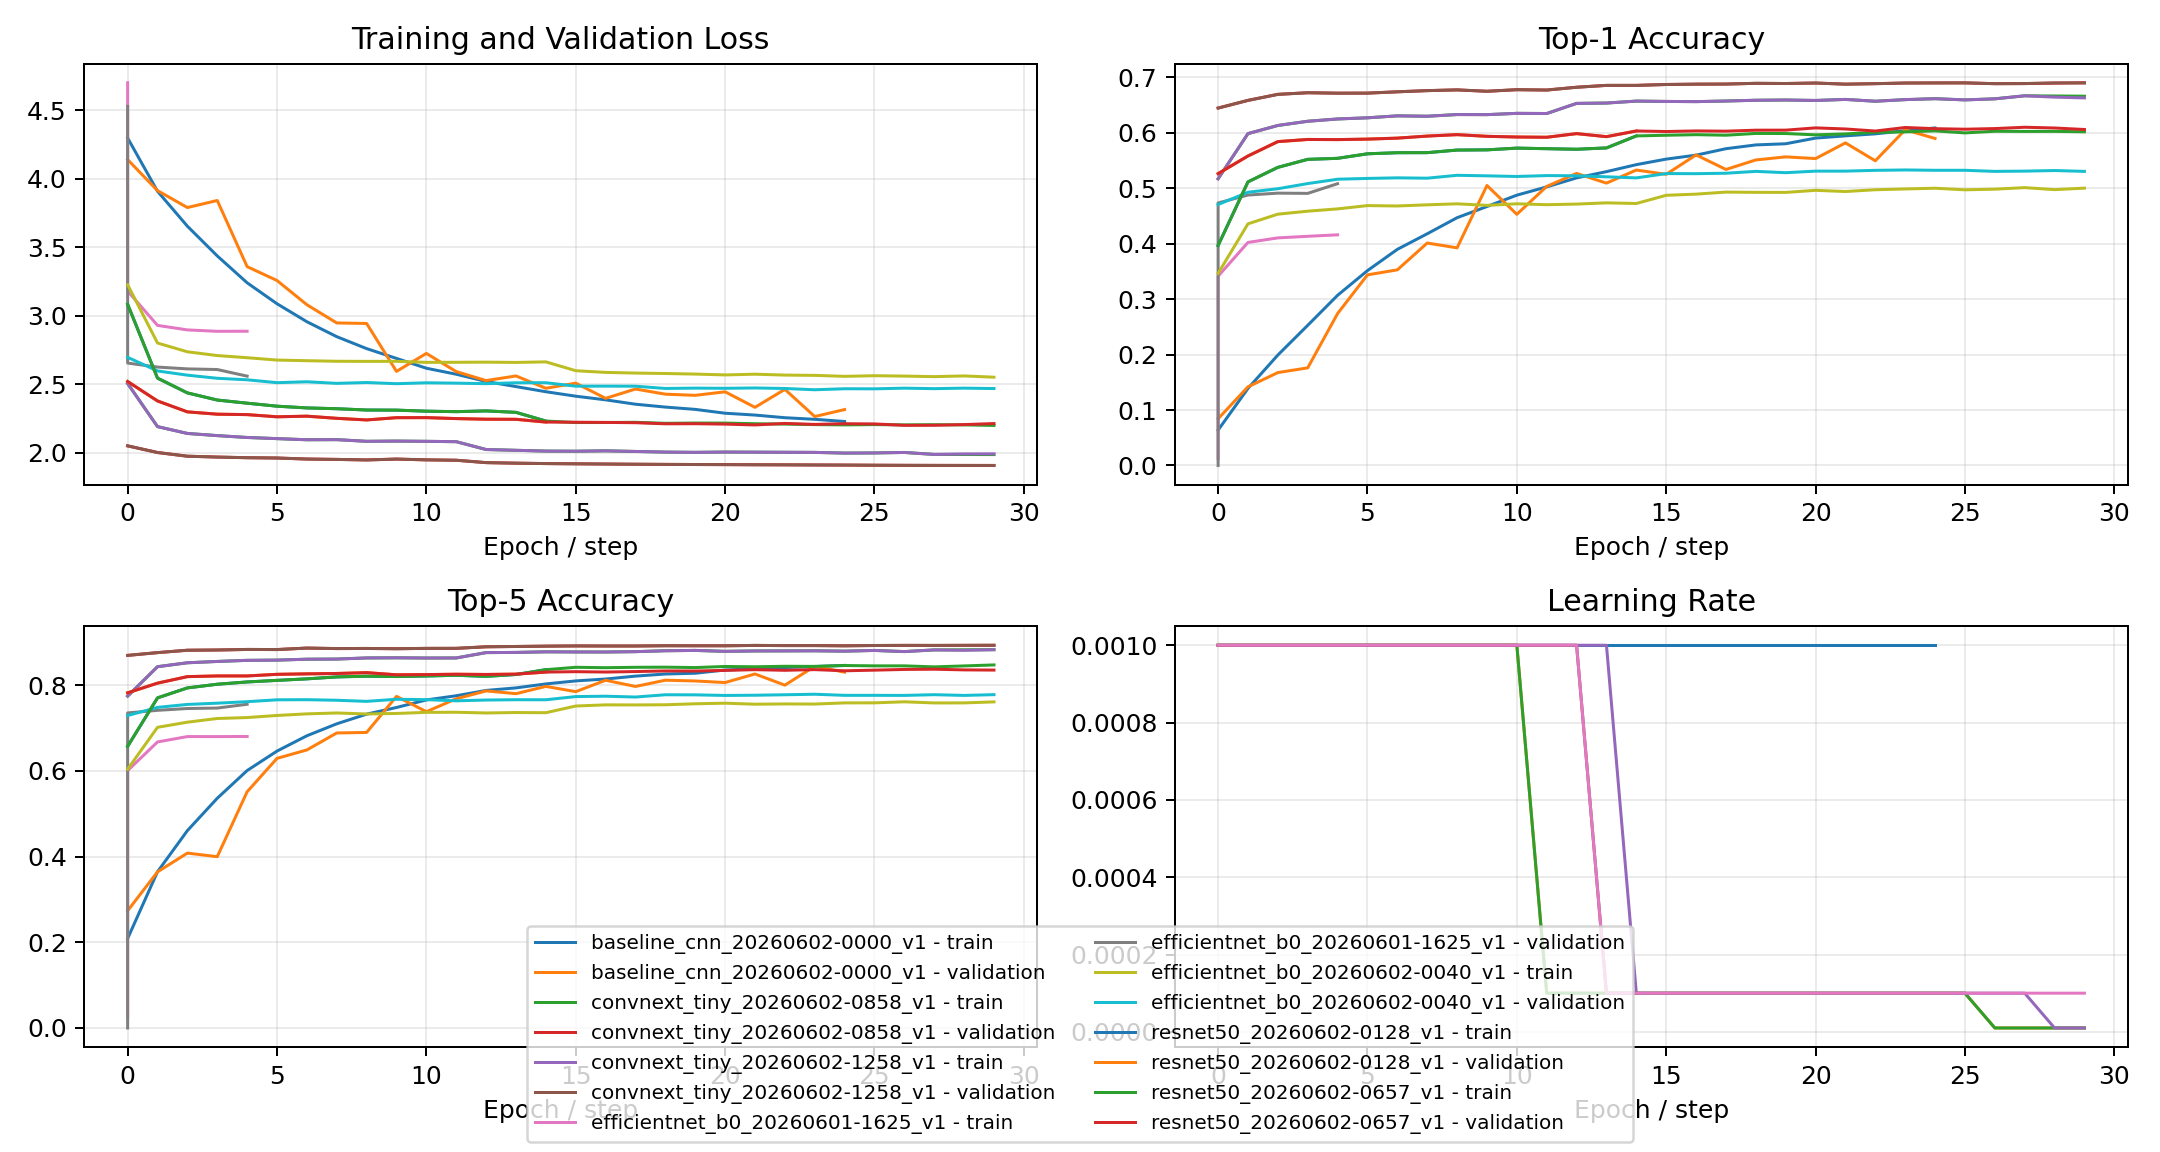

In [24]:
for figure_name in [
    "loss_curves.png",
    "top1_accuracy_curves.png",
    "top5_accuracy_curves.png",
    "macro_f1_curves.png",
    "learning_rate_curves.png",
    "all_scalar_metrics_overview.png",
]:
    display(Markdown(f"**{figure_name}**"))
    display_png(POSTPROCESS_FIGURES_DIR / "training_curves" / figure_name, width=920)


### Overfitting and Underfitting Diagnostics

The diagnostic summary uses conservative rules over the extracted loss and accuracy trends. It is a debugging aid, not a replacement for inspecting the actual curves and class-level errors.


In [25]:
training_diagnostics = load_report_json(POSTPROCESS_REPORTS_DIR / "training_diagnostics.json")
if training_diagnostics:
    display(pd.DataFrame([
        {
            "status": training_diagnostics.get("status"),
            "evidence": "; ".join(training_diagnostics.get("evidence", [])),
            "recommended_actions": "; ".join(training_diagnostics.get("recommended_actions", [])),
        }
    ]))


,status,evidence,recommended_actions
0,no_major_issue_detected,Training loss decreases across the logged epochs.,Inspect class-level errors and calibration bef...


### Model Comparison Overview

The overview is split into one table and separate top-1, top-5, macro-F1, and latency figures. Separate plots make small differences easier to inspect than a single combined chart, especially when models have different run durations, convergence behavior, and inference cost.


In [ ]:
comparison_overview_rows = [
    manifest_to_comparison_row(manifest)
    for manifest in candidate_manifests
    if manifest and isinstance(manifest.get("metrics"), dict)
]
comparison_metrics = pd.DataFrame(comparison_overview_rows)
if not comparison_metrics.empty:
    comparison_metrics["model_key"] = comparison_metrics["model"].astype(str)
    comparison_metrics["model"] = comparison_metrics["model_key"].map(MODEL_DISPLAY_NAMES).fillna(comparison_metrics["model_key"])
    comparison_metrics = comparison_metrics.sort_values(["top5", "macro_f1"], ascending=False, na_position="last")

comparison_plot_dir = POSTPROCESS_FIGURES_DIR / "model_comparison"
comparison_outputs = save_global_model_comparison_plots(comparison_metrics, comparison_plot_dir)

if comparison_metrics.empty:
    print("No completed model metrics are available for comparison.")
else:
    display(comparison_metrics[["model", "model_key", "top1", "top5", "macro_f1", "latency_ms"]])
    for figure_name in [
        "model_top1_accuracy.png",
        "model_top5_accuracy.png",
        "model_macro_f1.png",
        "model_latency_ms.png",
    ]:
        display(Markdown(f"**{figure_name}**"))
        display_png(comparison_plot_dir / figure_name, width=760)


In [ ]:
MODEL_SECTION_SPECS = {
    "baseline_cnn": {
        "title": "Baseline CNN Results",
        "model_name": "baseline_cnn",
        "config_path": "configs/baseline_cnn.yaml",
        "architecture": "Original custom CNN with three pooled two-convolution Conv-BN-ReLU blocks, two late 256-channel convolutions without intervening pooling, adaptive average pooling, dropout, and a linear classifier.",
        "command": "KMP_DUPLICATE_LIB_OK=TRUE python scripts/train.py --config configs/baseline_cnn.yaml --index-csv data/reports/dataset_index.csv --epochs 10 --log-level INFO",
        "version": None,
    },
    "baseline_cnn_simple": {
        "title": "Simpler CNN Full-Schedule Results",
        "model_name": "baseline_cnn_local",
        "config_path": "configs/baseline_cnn_simple.yaml",
        "architecture": "Simpler CNN architecture with single-convolution blocks, 16/32/64 channels, max-pooling after each block, adaptive average pooling, dropout, and a linear classifier. This isolates architecture simplification under a fuller baseline-style schedule.",
        "command": "KMP_DUPLICATE_LIB_OK=TRUE python scripts/train.py --config configs/baseline_cnn_simple.yaml --index-csv data/reports/dataset_index.csv --epochs 30 --log-level INFO",
        "version": "vfull1",
    },
    "efficientnet_b0": {
        "title": "EfficientNet-B0 Results",
        "model_name": "efficientnet_b0",
        "config_path": "configs/efficientnet_b0.yaml",
        "architecture": "Transfer-learning EfficientNet-B0 backbone with a Food-101 classifier head.",
        "command": "KMP_DUPLICATE_LIB_OK=TRUE python scripts/train.py --config configs/efficientnet_b0.yaml --index-csv data/reports/dataset_index.csv --log-level INFO",
        "version": None,
    },
    "resnet50": {
        "title": "ResNet-50 Results",
        "model_name": "resnet50",
        "config_path": "configs/resnet50.yaml",
        "architecture": "Transfer-learning ResNet-50 bottleneck backbone with the final fully connected layer replaced for Food-101.",
        "command": "KMP_DUPLICATE_LIB_OK=TRUE python scripts/train.py --config configs/resnet50.yaml --index-csv data/reports/dataset_index.csv --epochs 5 --log-level INFO",
        "version": None,
    },
    "convnext_tiny": {
        "title": "ConvNeXt-Tiny Results",
        "model_name": "convnext_tiny",
        "config_path": "configs/convnext_tiny.yaml",
        "architecture": "Transfer-learning ConvNeXt-Tiny backbone with a replaced Food-101 classifier head.",
        "command": "KMP_DUPLICATE_LIB_OK=TRUE python scripts/train.py --config configs/convnext_tiny.yaml --index-csv data/reports/dataset_index.csv --epochs 5 --log-level INFO",
        "version": None,
    },
    "baseline_cnn_local": {
        "title": "Local CNN Baseline Results",
        "model_name": "baseline_cnn_local",
        "config_path": "configs/baseline_cnn_local.yaml",
        "architecture": "The same simpler CNN architecture as the full-schedule simple baseline, but with batch size 8, shorter patience, lighter label smoothing, and a local-friendly schedule. This isolates the loss from local training constraints.",
        "command": "KMP_DUPLICATE_LIB_OK=TRUE python scripts/train.py --config configs/baseline_cnn_local.yaml --index-csv data/processed/<cache_hash>/cached_index.csv --device auto --batch-size 8 --log-level INFO",
        "version": "vlocal1",
    },
}

def section_manifest(spec: dict) -> dict | None:
    manifests = [resolved_manifest(item) for item in list_run_manifests(PROJECT_ROOT)]
    matches = []
    for manifest in manifests:
        if manifest is None or str(manifest.get("model_name")) != spec["model_name"]:
            continue
        if spec.get("version") and str(manifest.get("model_version")) != spec["version"]:
            continue
        matches.append(manifest)
    if not matches:
        return None
    return sorted(matches, key=lambda item: str(item.get("timestamp", "")), reverse=True)[0]


def run_dir_for_manifest(manifest: dict) -> Path:
    manifest_path = manifest.get("_manifest_path")
    if manifest_path:
        return Path(manifest_path).expanduser().resolve().parent
    run_dir = manifest.get("run_dir")
    if run_dir:
        return Path(run_dir).expanduser().resolve()
    return PROJECT_ROOT / "outputs" / "runs" / str(manifest["run_name"])


def display_model_result_section(spec_key: str) -> dict | None:
    spec = MODEL_SECTION_SPECS[spec_key]
    display(Markdown(f"#### Architecture summary\n{spec['architecture']}"))
    manifest = section_manifest(spec)
    config_path = PROJECT_ROOT / spec["config_path"]
    if config_path.is_file():
        section_config = load_config(config_path, project_root=PROJECT_ROOT)
        training = section_config["training"]
        display(pd.DataFrame([{
            "config": spec["config_path"],
            "batch_size": training.get("batch_size"),
            "optimizer": training.get("optimizer"),
            "lr": training.get("lr_head", training.get("learning_rate")),
            "weight_decay": training.get("weight_decay"),
            "scheduler": training.get("scheduler"),
            "dropout": section_config["model"].get("dropout"),
            "label_smoothing": training.get("label_smoothing"),
        }]))

    if manifest is None:
        print("Run not available")
        print(f"Generate it with: {spec['command']}")
        return None

    run_dir = run_dir_for_manifest(manifest)
    display(pd.DataFrame([manifest_to_comparison_row(manifest)]))

    tensorboard_dir = artifact_path(manifest, "tensorboard_dir") or (run_dir / "tensorboard")
    if tensorboard_dir and Path(tensorboard_dir).is_dir():
        curve_dir = run_dir / "figures" / "training_curves"
        save_training_curve_plots(load_tensorboard_scalars(tensorboard_dir), curve_dir)
        for figure_name in [
            "loss_curves.png",
            "top1_accuracy_curves.png",
            "top5_accuracy_curves.png",
            "macro_f1_curves.png",
            "learning_rate_curves.png",
        ]:
            display(Markdown(f"**{figure_name}**"))
            display_png(curve_dir / figure_name, width=720)
    else:
        print("TensorBoard logs not available for this run.")

    confusion_csv = artifact_path(manifest, "confusion_csv")
    if confusion_csv and confusion_csv.is_file():
        matrix, class_names_for_confusion = load_confusion_matrix_csv(confusion_csv)
        class_report = build_classification_report_from_confusion(matrix, class_names_for_confusion)
        display(Markdown("**Top-10 best classes**"))
        display(top_best_classes(class_report, top_n=10)[["class_name", "accuracy", "precision", "f1", "support"]])
        display(Markdown("**Top-10 worst classes**"))
        display(top_worst_classes(class_report, top_n=10)[["class_name", "accuracy", "precision", "f1", "support"]])
        display(Markdown("**Most common confusion pairs**"))
        display(top_misclassification_pairs(matrix, class_names_for_confusion, top_n=10))
    else:
        print("Confusion matrix report not available for this run.")

    calibration_json = artifact_path(manifest, "calibration_json")
    if calibration_json and calibration_json.is_file():
        calibration_dir = run_dir / "figures" / "calibration"
        report = load_calibration_report_json(calibration_json)
        save_calibration_artifacts_from_report(report, calibration_dir, run_dir / "reports")
        display_png(calibration_dir / "reliability_diagram.png", width=520)
    else:
        print("Calibration report not available for this run.")

    misclassified_csv = artifact_path(manifest, "misclassified_csv")
    predictions_csv = artifact_path(manifest, "predictions_csv")
    if predictions_csv and predictions_csv.is_file():
        display(pd.read_csv(predictions_csv).head(8))
    elif misclassified_csv and misclassified_csv.is_file():
        display(pd.read_csv(misclassified_csv).sort_values("confidence", ascending=False).head(8))
    else:
        print("Prediction or misclassification examples are not available for this run.")
    return manifest


### Baseline CNN Results


In [ ]:
baseline_section_manifest = display_model_result_section("baseline_cnn")


### Simpler CNN Full-Schedule Results

This section is for the intentionally simpler CNN architecture trained with a fuller baseline-style schedule. It is the comparison point for estimating accuracy loss due to model simplification, separate from local under-training.


In [ ]:
simple_full_schedule_manifest = display_model_result_section("baseline_cnn_simple")


### EfficientNet-B0 Results


In [ ]:
efficientnet_section_manifest = display_model_result_section("efficientnet_b0")


### ResNet-50 Results


In [ ]:
resnet_section_manifest = display_model_result_section("resnet50")


### ConvNeXt-Tiny Results


In [ ]:
convnext_section_manifest = display_model_result_section("convnext_tiny")


### Local CNN Baseline Results

This section uses the simpler CNN architecture with local constraints. It is not expected to outperform transfer-learning models or the fuller-schedule CNN baselines; its purpose is to quantify what is lost when both architecture and local training budget are reduced.


In [ ]:
local_baseline_section_manifest = display_model_result_section("baseline_cnn_local")


### Baseline CNN Qualitative Top-5 Predictions

This figure follows the AlexNet-style qualitative top-5 template as a diagnostic only. It checks whether the baseline CNN's most probable alternatives are visually plausible for Food-101 images, where lighting, viewpoint, recipe realization, texture, and visually similar categories can make a single top-1 label too narrow.


In [ ]:
baseline_qualitative_path = None
if baseline_section_manifest is None:
    print("Run not available")
    print(MODEL_SECTION_SPECS["baseline_cnn"]["command"])
else:
    baseline_run_dir = run_dir_for_manifest(baseline_section_manifest)
    baseline_predictions = artifact_path(baseline_section_manifest, "predictions_csv")
    if baseline_predictions is None or not baseline_predictions.is_file():
        candidate_predictions = baseline_run_dir / "predictions" / f"{baseline_section_manifest['run_name']}_predictions.csv"
        baseline_predictions = candidate_predictions if candidate_predictions.is_file() else None
    if baseline_predictions is None:
        print("Baseline prediction CSV with top-5 probabilities is not available.")
        checkpoint = artifact_path(baseline_section_manifest, "checkpoint")
        if checkpoint:
            print("Generate it with:")
            print(f"KMP_DUPLICATE_LIB_OK=TRUE python scripts/evaluate.py --config configs/baseline_cnn.yaml --checkpoint {checkpoint} --index-csv data/reports/dataset_index.csv --split test")
    else:
        baseline_config = load_config(PROJECT_ROOT / "configs" / "baseline_cnn.yaml", project_root=PROJECT_ROOT)
        baseline_class_names = load_class_names(
            config=baseline_config,
            checkpoint_path=artifact_path(baseline_section_manifest, "checkpoint"),
            num_classes=int(baseline_config["model"]["num_classes"]),
        )
        baseline_qualitative_path = baseline_run_dir / "figures" / "baseline_top5_qualitative.png"
        plot_top5_prediction_panel(
            baseline_predictions,
            PROJECT_ROOT,
            baseline_class_names,
            baseline_qualitative_path,
            n_images=8,
            seed=int(config["project"]["seed"]),
        )
        display_png(baseline_qualitative_path, width=900)


### Baseline CNN Feature-Space Nearest Neighbors

Last-hidden-layer nearest-neighbor retrieval probes whether the baseline representation clusters visually or semantically similar foods. Feature-space distance is more meaningful than raw pixel distance because the hidden layer contains learned visual abstractions, but the result remains qualitative and does not prove causal interpretability.


In [ ]:
if baseline_section_manifest is None:
    print("Run not available")
elif not RUN_BASELINE_QUALITATIVE:
    print("Skipped feature-neighbor extraction because RUN_BASELINE_QUALITATIVE=False.")
    print("Set RUN_BASELINE_QUALITATIVE=True after a local baseline checkpoint and cached train/test index are available.")
else:
    print("Feature-neighbor extraction is intentionally guarded because it requires batched train/test feature extraction.")
    print("Use food101_cnn.evaluation.feature_retrieval.extract_hidden_features, save_feature_file, find_nearest_feature_neighbors, and plot_feature_neighbor_panel to write:")
    print("outputs/runs/<run_name>/reports/baseline_train_features.npz")
    print("outputs/runs/<run_name>/reports/baseline_test_features.npz")
    print("outputs/runs/<run_name>/figures/baseline_feature_neighbors.png")


### Data Augmentation and Overfitting

Label-preserving transformations artificially enlarge the training distribution and reduce sensitivity to accidental image conditions. For Food-101, augmentation must stay conservative because color, texture, local ingredients, and plating cues are discriminative. This project therefore emphasizes horizontal flips, padded resizing, mild rotation, and moderate color jitter, while avoiding vertical flips, aggressive random erasing, CutMix, and MixUp in the baseline discussion. That choice matches the dataset difficulty described for food recognition: foods vary in viewpoint, lighting, recipe realization, color, texture, and visual similarity across categories.


### Dropout

The baseline CNN uses dense `Dropout(p=dropout)` in the classifier head after `Flatten()` and before the final `Linear(256, num_classes)`. It does not use `Dropout2d` in the convolutional feature extractor. This placement regularizes deeper, class-specific activations where co-adaptation is more likely, while leaving early convolutional layers free to learn low-level edges, colors, and textures. Dropout is not assumed to be universally optimal; its value should be judged from validation loss and validation top-1/top-5 accuracy.


### Learning-Rate Reduction

The training code builds `ReduceLROnPlateau` when the config sets `training.scheduler: reduce_on_plateau`. In `fit()`, the scheduler observes validation top-5 accuracy, allowing larger initial Adam updates and smaller updates when validation improvement stalls. The AlexNet learning-rate reduction heuristic is useful historical motivation, but this project uses the actual configured PyTorch scheduler rather than manually following the AlexNet schedule.


### Pooling Placement in the Baseline CNN

Pooling reduces spatial resolution and improves translational robustness, but too much pooling too early can discard food details. The implemented baseline pools after the first three two-convolution blocks: `3->32`, `32->64`, and `64->128`. It then applies two 256-channel convolutional layers without intervening max-pooling and finishes with adaptive average pooling. This mirrors the late-stage idea from AlexNet in a limited way: several convolutional transformations refine higher-level features at the same spatial resolution before final downsampling. It does not mean the reference architecture has no late pooling; AlexNet connects conv3, conv4, and conv5 without intervening pooling, then pools afterward.


### Class-Level Performance Analysis

Food-101 classes are not equally easy: similar colors, plating styles, and ingredients can hide failures in the aggregate score. Per-class accuracy is computed as correct predictions for class *i* divided by samples whose true class is *i*, so it matches recall under this denominator. Precision and F1 are kept because they show whether a class is also over-predicted.


In [ ]:
per_class_metrics = display_csv(POSTPROCESS_REPORTS_DIR / "per_class_metrics.csv", rows=15)


### Best and Worst Performing Food Classes

The best and worst class tables make the error distribution visible. This avoids treating the single global confusion matrix as if every class contributed equally to the same failure mode.


In [ ]:
display(Markdown("**Top-10 best accuracy classes**"))
top_best_classes_table = display_csv(POSTPROCESS_REPORTS_DIR / "top10_best_classes.csv", rows=10)
display(Markdown("**Top-10 worst accuracy classes**"))
top_worst_classes_table = display_csv(POSTPROCESS_REPORTS_DIR / "top10_worst_classes.csv", rows=10)


### Confusion Matrix Analysis

The full normalized matrix shows broad structure, while best/worst-class subsets are easier to read and directly support targeted debugging. The off-diagonal table identifies which wrong labels are most common within a true class.


In [ ]:
for figure_name in [
    "confusion_matrix_full_normalized.png",
    "confusion_matrix_best10_normalized.png",
    "confusion_matrix_worst10_normalized.png",
    "top_misclassification_pairs.png",
]:
    display(Markdown(f"**{figure_name}**"))
    display_png(POSTPROCESS_FIGURES_DIR / "confusion" / figure_name, width=920)

top_pairs_table = display_csv(POSTPROCESS_REPORTS_DIR / "top_misclassification_pairs.csv", rows=20)


### Most Common Misclassifications

High-confidence wrong predictions are more important than random errors because they indicate mistakes the model presents as reliable. Low-confidence wrong predictions are useful for identifying ambiguous visual cases and threshold behavior.


In [ ]:
misclassified_examples = display_csv(POSTPROCESS_REPORTS_DIR / "misclassified_examples.csv", rows=15)


### Misclassified Image Galleries

These galleries are generated from saved prediction or misclassification records. If a source image is not present locally, the figure still marks the missing image so the report remains executable.


In [ ]:
for figure_name in [
    "high_confidence_wrong.png",
    "low_confidence_wrong.png",
    "worst_class_examples.png",
    "correct_high_confidence.png",
]:
    display(Markdown(f"**{figure_name}**"))
    display_png(POSTPROCESS_FIGURES_DIR / "errors" / figure_name, width=920)


### Calibration and Confidence Analysis

Calibration matters because the inference API returns probabilities. A high top-1 score is not enough if the probability scale is overconfident or underconfident; reliability diagrams and confidence histograms show whether confidence tracks empirical accuracy.


In [ ]:
display(Markdown("**Reliability diagram**"))
display_png(POSTPROCESS_FIGURES_DIR / "calibration" / "reliability_diagram.png", width=640)
display(Markdown("**Confidence histogram**"))
display_png(POSTPROCESS_FIGURES_DIR / "calibration" / "confidence_histogram.png", width=640)
calibration_metrics = load_report_json(POSTPROCESS_REPORTS_DIR / "calibration_metrics.json")
if calibration_metrics:
    display(pd.DataFrame([{
        "ece": calibration_metrics.get("ece"),
        "num_bins": calibration_metrics.get("num_bins"),
        "total": calibration_metrics.get("total"),
    }]))


### Grad-CAM Interpretability

Grad-CAM is used as a small diagnostic for the selected transfer-learning model. It can show which image regions influenced a class score, but it cannot prove causality or guarantee that the model has learned the intended food concept.


In [ ]:
gradcam_manifest = best_manifest or resolved_latest_run_for_model(REPORT_REFERENCE_MODEL)
gradcam_outputs = {}
gradcam_source = None
for candidate in [
    POSTPROCESS_REPORTS_DIR / "predictions_test.csv",
    artifact_path(gradcam_manifest, "predictions_csv"),
    POSTPROCESS_REPORTS_DIR / "misclassified_examples.csv",
    artifact_path(gradcam_manifest, "misclassified_csv"),
]:
    if candidate and Path(candidate).is_file():
        gradcam_source = Path(candidate)
        break

gradcam_checkpoint = artifact_path(gradcam_manifest, "checkpoint")
gradcam_model_name = str(gradcam_manifest.get("model_name", "")) if gradcam_manifest else ""

if gradcam_model_name == "baseline_cnn":
    print("Skipped Grad-CAM sets because the selected manifest is the baseline CNN, not a transfer-learning model.")
elif gradcam_source is None:
    print("Skipped Grad-CAM sets because no prediction or misclassification CSV is available.")
elif gradcam_checkpoint is None or not gradcam_checkpoint.is_file():
    print("Skipped Grad-CAM sets because no local checkpoint is available.")
else:
    gradcam_config = load_config(PROJECT_ROOT / manifest_config_path(gradcam_manifest), project_root=PROJECT_ROOT)
    gradcam_model = build_model(
        str(gradcam_config["model"]["name"]),
        num_classes=int(gradcam_config["model"]["num_classes"]),
        pretrained=False,
        dropout=float(gradcam_config["model"].get("dropout", 0.3)),
        freeze_backbone_initially=False,
    )
    checkpoint_payload = torch.load(gradcam_checkpoint, map_location="cpu")
    gradcam_model.load_state_dict(checkpoint_payload.get("model_state_dict", checkpoint_payload))
    class_names = load_class_names(
        config=gradcam_config,
        checkpoint_path=gradcam_checkpoint,
        num_classes=int(gradcam_config["model"]["num_classes"]),
    )
    gradcam_device = "cuda" if torch.cuda.is_available() else "cpu"
    gradcam_outputs = save_gradcam_sets_from_predictions(
        gradcam_model,
        pd.read_csv(gradcam_source),
        class_names=class_names,
        transform=build_eval_transform(gradcam_config),
        output_dir=POSTPROCESS_FIGURES_DIR / "gradcam",
        project_root=PROJECT_ROOT,
        model_name=gradcam_model_name,
        device=gradcam_device,
        examples_per_set=3,
    )

for set_name, paths in gradcam_outputs.items():
    display(Markdown(f"**{set_name}**"))
    if not paths:
        print(f"No Grad-CAM images generated for {set_name}.")
    for image_path in paths:
        display_png(image_path, width=360)


### Final Model Selection

The selected model is ranked by top-5 accuracy first and macro F1 second. This is appropriate for Food-101 because top-5 captures whether visually plausible alternatives still include the correct dish, while macro F1 guards against hiding weak classes behind aggregate accuracy.


In [ ]:
if best_manifest:
    display(pd.DataFrame([manifest_to_comparison_row(best_manifest)]))
else:
    print("No completed model run is available for final selection.")


### Model Improvement Recommendations

Recommendations below are derived from the generated diagnostics and error tables. They should be interpreted as next experiment choices, not as claims that a single change will fix the model.


In [ ]:
recommendations = []
if training_diagnostics:
    recommendations.extend(training_diagnostics.get("recommended_actions", []))
if top_pairs_table is not None and not top_pairs_table.empty:
    recommendations.append("Inspect the top off-diagonal confusion pairs and report top-k predictions for visually similar dishes.")
if top_worst_classes_table is not None and not top_worst_classes_table.empty:
    recommendations.append("Review the worst classes for label quality, image preprocessing failures, and targeted conservative augmentation.")
if calibration_metrics and calibration_metrics.get("ece") is not None and float(calibration_metrics["ece"]) > 0.10:
    recommendations.append("Review label smoothing and fit temperature scaling on validation data before reporting probability thresholds.")
if not comparison_metrics.empty:
    baseline_row = comparison_metrics[comparison_metrics["model_key"] == "baseline_cnn"]
    best_row = comparison_metrics.sort_values("top5", ascending=False).head(1)
    if not baseline_row.empty and not best_row.empty and float(best_row.iloc[0]["top5"]) > float(baseline_row.iloc[0]["top5"]):
        recommendations.append("Use pretrained backbones for final Food-101 reporting; keep the custom CNN as the pedagogical baseline.")
    if not best_row.empty and str(best_row.iloc[0]["model_key"]) in {"resnet50", "convnext_tiny"}:
        recommendations.append("If local latency or memory is limiting, compare against EfficientNet-B0 or add a lightweight backbone such as MobileNetV3.")
if gradcam_outputs:
    recommendations.append("Use Grad-CAM examples to check whether attention falls on food regions instead of plates, hands, or background context.")

recommendations = list(dict.fromkeys(recommendations))
display(Markdown("\n".join(f"- {item}" for item in recommendations) if recommendations else "No automatic recommendations were generated."))


## 19. Inference and Export

The inference CLI supports a single image or a folder, top-k probabilities, confidence thresholding, and optional CSV output. Export supports native PyTorch `.pt` packages and ONNX when the local environment supports it.

In [ ]:
selected_manifest = best_manifest or resolved_latest_run_for_model(REPORT_REFERENCE_MODEL)
checkpoint_path = artifact_path(selected_manifest, "checkpoint")
if RUN_INFERENCE_EXPORT and selected_manifest and checkpoint_path and checkpoint_path.is_file():
    run_cli([
        sys.executable,
        "scripts/export_model.py",
        "--config",
        manifest_config_path(selected_manifest),
        "--checkpoint",
        checkpoint_path,
    ])
else:
    print("Skipped inference/export. Enable RUN_INFERENCE_EXPORT after a local checkpoint exists.")

$ /Users/alex/miniconda3/envs/food101-cnn/bin/python scripts/export_model.py --config configs/convnext_tiny.yaml --checkpoint /Users/alex/Documents/IA_aero_upm/food101-cnn/outputs/runs/convnext_tiny_20260602-1258_v1/checkpoints/convnext_tiny_20260602-1258_v1_best_model.pt
pt_export=/Users/alex/Documents/IA_aero_upm/food101-cnn/outputs/runs/convnext_tiny_20260602-1258_v1/exports/convnext_tiny_20260602-1258_v1_model.pt
onnx_export=failed: No module named 'onnxscript'
run_name=convnext_tiny_20260602-1258_v1
run_dir=/Users/alex/Documents/IA_aero_upm/food101-cnn/outputs/runs/convnext_tiny_20260602-1258_v1


## 20. Conclusions and Recommended Improvements

The conclusion should be based on the displayed run manifests, separate model-comparison figures, per-model training curves, class-level metrics, confusion subsets, calibration figures, misclassification galleries, and qualitative baseline diagnostics. The from-scratch CNN is a pedagogical baseline; transfer-learning models should be selected only according to generated top-5 accuracy, macro F1, calibration, latency, and class-level behavior. The local CNN config is included for reproducible Mac/local experimentation and is not expected to outperform pretrained backbones.
